<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
پیش‌بینی دست دوم</font>
</h1>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین می‌خواهیم به پیش‌بینی قیمت ماشین‌های دست دوم بر اساس ویژگی‌هایی بپردازیم که در مجموعه‌ی دادگانی هست که به پیوست در اختیار شما قرار گرفته است. 
<br>
</font>
</p>


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">مجموعه‌داده</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
مجموعه داده که در اختیار شما قرار گرفته حاوی اطلاعاتی درباره خودروهای دست دوم موجود برای فروش است. این شامل ویژگی های زیر است::

</font>
</p>

<center>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

| ویژگی | توضیح |
| :---: | :---: |
| name| برند و مدل خودرو  |
| Location | مکانی که ماشین برای فروش در دسترس است |
| Year | سال ساخت خودرو |
| Kilometers_Driven |  مسافت پیموده شده توسط خودرو|
| Fuel_Type | ایستادن |
| Transmission | نوع جعبه دنده (اتوماتیک یا دستی) |
| Mileage | کیلومترهای طی شده توسط خودرو در 1 لیتر سوخت در شرایط مختلف رانندگی |
| Engine | ظرفیت موتور بر حسب سی سی|
| Power | حداکثر قدرت تولید شده توسط موتور بر حسب اسب بخار |
| Seats | تعداد صندلی های خودرو |
| New_Price | پایین رفتن از پله‌ها |
| Price | نشستن |

</font>
</p>
</center>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در ابتدا مجموعه‌داده‌های آموزش (<code>train</code>) و آزمون (<code>test</code>) از فایل‌های موجود در پوشه بخوانید. در صورت تمایل می‌توانید بخشی از مجموعه‌ی آموزشی را جدا کرده و برای اعتبارسنجی (<code>validation</code>) استفاده کنید.
    </font>
</p>


In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
train = pd.read_csv(r"D:\quera\week 8\tamrin\used cars\used_cars_train_data.csv")
test = pd.read_csv(r"D:\quera\week 8\tamrin\used cars\used_cars_test_data.csv")

In [4]:
print(train.shape)
print(test.shape)

(4514, 12)
(1505, 11)


In [5]:
train.head(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74


In [6]:
test.head(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,Hyundai Xcent 1.2 Kappa AT SX Option,Kochi,2016,45560,Petrol,Automatic,First,16.9 kmpl,1197 CC,82 bhp,5.0
1,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,Pune,2009,118000,Diesel,Manual,First,12.8 kmpl,2494 CC,102 bhp,8.0
2,Maruti Eeco 7 Seater Standard,Chennai,2016,55000,Petrol,Manual,First,15.1 kmpl,1196 CC,73 bhp,7.0
3,Audi A4 New 2.0 TDI Multitronic,Delhi,2012,60000,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0
4,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,Chennai,2007,145000,Diesel,Manual,First,12.8 kmpl,2494 CC,102 bhp,8.0


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">تحلیل اکتشافی داده</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در ابتدا پیشنهاد می‌کنیم کمی به بررسی دقیق‌تر و آماری داده‌هایی که در دسترس‌تان است بپردازید و در صورت علاقه نمودارهایی را جهت بررسی توزیع‌های داده رسم کنید.
<span style="color:orange">(اختیاری)</span>
</font>
</p>

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4514 entries, 0 to 4513
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               4514 non-null   object 
 1   Location           4514 non-null   object 
 2   Year               4514 non-null   int64  
 3   Kilometers_Driven  4514 non-null   int64  
 4   Fuel_Type          4514 non-null   object 
 5   Transmission       4514 non-null   object 
 6   Owner_Type         4514 non-null   object 
 7   Mileage            4513 non-null   object 
 8   Engine             4486 non-null   object 
 9   Power              4486 non-null   object 
 10  Seats              4481 non-null   float64
 11  Price              4514 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 423.3+ KB


In [8]:
train.isnull().sum()/train.shape[0]*100

Name                 0.000000
Location             0.000000
Year                 0.000000
Kilometers_Driven    0.000000
Fuel_Type            0.000000
Transmission         0.000000
Owner_Type           0.000000
Mileage              0.022153
Engine               0.620292
Power                0.620292
Seats                0.731059
Price                0.000000
dtype: float64

<p dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium;color:#0099cc"><font face="vazir" size=3><i>دیتای train ما 4514 تا ماشین داره و 12 ستون بیشتر ستون ها متنی هستن مثل برند شهر نوع سوخت و دنده بعضی ها عددی مثل سال ساخت کیلومتر طی شده تعداد صندلی و قیمت ستون هدف Price کامله ولی بعضی ستون ها مثل Mileage Engine Power و Seats چندتا خالی دارن که باید پر بشن دیتای اصلی قابل استفاده است فقط باید متن ها عددی بشن و خالی ها درست بشن بعدش می تونیم مدل بسازیم و پیش بینی قیمت ماشین ها رو شروع کنیم
</i></font></p>

In [9]:
train['Mileage']=pd.to_numeric(train['Mileage'].str.split().str[0],errors='coerce')
train['Power']=pd.to_numeric(train['Power'].str.split().str[0],errors='coerce')
train['Engine']=pd.to_numeric(train['Engine'].str.split().str[0],errors='coerce')

In [10]:
test['Mileage']=pd.to_numeric(test['Mileage'].str.split().str[0],errors='coerce')
test['Power']=pd.to_numeric(test['Power'].str.split().str[0],errors='coerce')
test['Engine']=pd.to_numeric(test['Engine'].str.split().str[0],errors='coerce')

In [11]:
train=train.rename(columns={'Mileage':'Mileage_kmpl','Power':'Power_bhp','Engine':'Engine_cc'})
test=test.rename(columns={'Mileage':'Mileage_kmpl','Power':'Power_bhp','Engine':'Engine_cc'})


<p dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium;color:#0099cc"><font face="vazir" size=3><i>
این ستون هادارای واحد بودن که برای برسرسی های اماری اختلال ایجاد میکردن.واحد هارو برداشتیم 
</i></font></p>

In [12]:
categorical_cols=['Name','Location','Fuel_Type','Transmission','Owner_Type']
numeric_cols=['Year','Kilometers_Driven','Price','Mileage_kmpl','Power_bhp','Engine_cc','Seats']

In [13]:
for i in train[categorical_cols]:
    print(train[i].value_counts())
    print('***'*10)

Name
Mahindra XUV500 W8 2WD                           37
Maruti Swift VDI                                 30
Honda City 1.5 S MT                              29
Maruti Ritz VDi                                  26
Maruti Swift VDI BSIV                            26
                                                 ..
Audi Q7 4.2 FSI quattro                           1
Maruti 800 AC BSIII                               1
Chevrolet Captiva LTZ VCDi                        1
Mahindra Scorpio 2009-2014 VLX 4WD AT 7S BSIV     1
Volkswagen Jetta 2007-2011 1.9 TDI Trendline      1
Name: count, Length: 1645, dtype: int64
******************************
Location
Mumbai        603
Hyderabad     547
Coimbatore    497
Kochi         472
Pune          461
Delhi         418
Kolkata       414
Chennai       355
Jaipur        311
Bangalore     269
Ahmedabad     167
Name: count, dtype: int64
******************************
Fuel_Type
Diesel      2393
Petrol      2068
CNG           44
LPG            8
Electric  

<p dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium;color:#0099cc"><font face="vazir" size=3><i>ستون name مدل کامل ماشین رو نشون میده و تعداد حالت های مختلفش خیلی زیاده به خاطر همین مستقیم برای مدل مناسب نیست و بهتره فقط برند ازش جدا بشه
ستون Location چند شهر مشخص داره و تعداد رکوردها تقریباً بین شهرها پخش شده، ولی Mumbai و Hyderabad بیشترین داده رو دارن.
پس لوکیشن احتمالاً روی قیمت تاثیر داره.
ستون Fuel_Type بیشتر ماشین‌ها یا Diesel هستن یا Petrol و بقیه خیلی کم هستن.
یعنی این ستون نامتوازن ولی قابل استفاده است.
ستون Transmission هم ساده و تمیزه:
بیشتر ماشین‌ها Manual هستن و تعداد کمتری Automatic.
ستون Owner_Type هم بیشتر ماشین‌ها First owner هستن.
یعنی بیشتر خودروها دست اول فروخته میشن.
</i></font></p>

In [14]:
'''unique_names=train['Name'].unique()
dataframe_uniquenames=pd.DataFrame(unique_names,columns=['Name'])
dataframe_uniquenames.to_csv('unique_carnames.csv',index=False)'''

"unique_names=train['Name'].unique()\ndataframe_uniquenames=pd.DataFrame(unique_names,columns=['Name'])\ndataframe_uniquenames.to_csv('unique_carnames.csv',index=False)"

In [15]:
train['Brand']=train['Name'].str.split().str[0]
test['Brand']=test['Name'].str.split().str[0]
train.loc[(train['Brand']=='Land')&(train['Name'].str.startswith('Land Rover')),'Brand']='Land Rover'
test.loc[(train['Brand']=='Land')&(train['Name'].str.startswith('Land Rover')),'Brand']='Land Rover'

print(train['Brand'].value_counts())

Brand
Maruti           921
Hyundai          824
Honda            461
Toyota           322
Mercedes-Benz    235
Volkswagen       224
Ford             220
Mahindra         208
BMW              195
Audi             180
Tata             135
Skoda            130
Renault          104
Chevrolet         91
Nissan            65
Land Rover        40
Jaguar            33
Fiat              24
Mini              22
Mitsubishi        19
Volvo             18
Porsche           14
Jeep              14
Datsun            11
Smart              1
Ambassador         1
Isuzu              1
ISUZU              1
Name: count, dtype: int64


In [16]:
train['Brand']=train['Brand'].str.title()
test['Brand']=test['Brand'].str.title()
print(train['Brand'].value_counts())

Brand
Maruti           921
Hyundai          824
Honda            461
Toyota           322
Mercedes-Benz    235
Volkswagen       224
Ford             220
Mahindra         208
Bmw              195
Audi             180
Tata             135
Skoda            130
Renault          104
Chevrolet         91
Nissan            65
Land Rover        40
Jaguar            33
Fiat              24
Mini              22
Mitsubishi        19
Volvo             18
Porsche           14
Jeep              14
Datsun            11
Isuzu              2
Smart              1
Ambassador         1
Name: count, dtype: int64


<p dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium;color:#0099cc"><font face="vazir" size=3><i>بعضی برندها با حروف بزرگ و کوچک مختلف نوشته شده بودن مثل isuzu و ISUZU که در واقع یکی هستن برای همین همه برندها رو به یک شکل نوشتیم تا مدل دچار اشتباه نشه
</i></font></p>

In [17]:
train['Model'] = train.apply(lambda x: x['Name'][len(x['Brand']):].strip(), axis=1)
test['Model']  = test.apply(lambda x: x['Name'][len(x['Brand']):].strip(), axis=1)


In [18]:
train.describe()

,Year,Kilometers_Driven,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price
count,4514.000000,4.514000e+03,4513.000000,4486.000000,4404.000000,4481.000000,4514.000000
mean,2013.365086,5.910450e+04,18.095839,1617.950067,113.064513,5.282749,9.453618
std,3.225629,1.035393e+05,4.553446,589.055115,52.696331,0.811023,11.121233
min,1998.000000,1.710000e+02,0.000000,72.000000,34.200000,0.000000,0.440000
25%,2011.000000,3.400000e+04,15.100000,1198.000000,76.000000,5.000000,3.500000
50%,2014.000000,5.300000e+04,18.150000,1493.000000,94.000000,5.000000,5.600000
75%,2016.000000,7.300000e+04,20.920000,1984.000000,138.100000,5.000000,9.942500
max,2019.000000,6.500000e+06,33.540000,5461.000000,550.000000,10.000000,160.000000


In [19]:
train

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price,Brand,Model
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75,Maruti,Wagon R LXI CNG
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,Hyundai,Creta 1.6 CRDi SX Option
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,Honda,Jazz V
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,Maruti,Ertiga VDI
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,Audi,A4 New 2.0 TDI Multitronic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4509,Honda City 1.5 S MT,Delhi,2012,65055,Petrol,Manual,Second,17.00,1497.0,118.00,5.0,4.25,Honda,City 1.5 S MT
4510,BMW 3 Series 320d Sport Line,Mumbai,2014,23000,Diesel,Automatic,First,18.88,1995.0,184.00,5.0,19.90,Bmw,3 Series 320d Sport Line
4511,Volkswagen Jetta 2007-2011 1.9 TDI Trendline,Chennai,2009,60000,Diesel,Manual,First,15.00,1896.0,105.00,5.0,4.00,Volkswagen,Jetta 2007-2011 1.9 TDI Trendline
4512,Maruti Swift Dzire LXI,Kochi,2013,59350,Petrol,Manual,First,19.10,1197.0,85.80,5.0,4.16,Maruti,Swift Dzire LXI


In [20]:
train.describe(include='object')

,Name,Location,Fuel_Type,Transmission,Owner_Type,Brand,Model
count,4514,4514,4514,4514,4514,4514,4514
unique,1645,11,5,2,4,27,1645
top,Mahindra XUV500 W8 2WD,Mumbai,Diesel,Manual,First,Maruti,XUV500 W8 2WD
freq,37,603,2393,3218,3709,921,37


In [21]:
print('The dataframe contains',train.duplicated().sum(), 'duplicate rows')
print('The dataframe contains',test.duplicated().sum(), 'duplicate rows')
test.drop_duplicates()


The dataframe contains 0 duplicate rows
The dataframe contains 1 duplicate rows


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Brand,Model
0,Hyundai Xcent 1.2 Kappa AT SX Option,Kochi,2016,45560,Petrol,Automatic,First,16.90,1197.0,82.0,5.0,Hyundai,Xcent 1.2 Kappa AT SX Option
1,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,Pune,2009,118000,Diesel,Manual,First,12.80,2494.0,102.0,8.0,Toyota,Innova 2.5 G (Diesel) 7 Seater BS IV
2,Maruti Eeco 7 Seater Standard,Chennai,2016,55000,Petrol,Manual,First,15.10,1196.0,73.0,7.0,Maruti,Eeco 7 Seater Standard
3,Audi A4 New 2.0 TDI Multitronic,Delhi,2012,60000,Diesel,Automatic,Second,15.20,1968.0,140.8,5.0,Audi,A4 New 2.0 TDI Multitronic
4,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,Chennai,2007,145000,Diesel,Manual,First,12.80,2494.0,102.0,8.0,Toyota,Innova 2.5 G (Diesel) 7 Seater BS IV
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1500,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.40,1248.0,74.0,5.0,Maruti,Swift VDI
1501,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120.0,71.0,5.0,Hyundai,Xcent 1.1 CRDi S
1502,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498.0,112.0,8.0,Mahindra,Xylo D4 BSIV
1503,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.90,998.0,67.1,5.0,Maruti,Wagon R VXI


In [22]:
train[train['Mileage_kmpl'].isnull()|train['Engine_cc'].isnull()|train['Power_bhp'].isnull()|train['Seats'].isnull()]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price,Brand,Model
76,Ford Fiesta 1.4 SXi TDCi,Jaipur,2008,111111,Diesel,Manual,First,17.80,1399.0,NaN,5.0,2.00,Ford,Fiesta 1.4 SXi TDCi
79,Hyundai Santro Xing XL,Hyderabad,2005,87591,Petrol,Manual,First,0.00,1086.0,NaN,5.0,1.30,Hyundai,Santro Xing XL
89,Hyundai Santro Xing XO,Hyderabad,2007,73745,Petrol,Manual,First,17.00,1086.0,NaN,5.0,2.10,Hyundai,Santro Xing XO
120,Hyundai Santro Xing XL eRLX Euro III,Mumbai,2005,102000,Petrol,Manual,Second,17.00,1086.0,NaN,5.0,0.85,Hyundai,Santro Xing XL eRLX Euro III
143,Hyundai Santro Xing XO eRLX Euro II,Kochi,2008,80759,Petrol,Manual,Third,17.00,1086.0,NaN,5.0,1.67,Hyundai,Santro Xing XO eRLX Euro II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152,Land Rover Range Rover 3.0 D,Mumbai,2003,75000,Diesel,Automatic,Second,0.00,NaN,NaN,NaN,16.11,Land Rover,Range Rover 3.0 D
4229,Hyundai Santro Xing XG,Bangalore,2005,79000,Petrol,Manual,Second,17.00,NaN,NaN,NaN,1.65,Hyundai,Santro Xing XG
4351,Maruti Esteem LX BSII,Jaipur,2003,55000,Petrol,Manual,Third,15.90,1298.0,NaN,5.0,0.70,Maruti,Esteem LX BSII
4354,Toyota Etios Liva GD,Delhi,2012,72351,Diesel,Manual,First,23.59,1364.0,NaN,5.0,2.65,Toyota,Etios Liva GD


In [23]:
test.isnull().sum()

Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage_kmpl          1
Engine_cc             8
Power_bhp            33
Seats                 9
Brand                 0
Model                 0
dtype: int64

In [24]:
train.isnull().sum()

Name                   0
Location               0
Year                   0
Kilometers_Driven      0
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage_kmpl           1
Engine_cc             28
Power_bhp            110
Seats                 33
Price                  0
Brand                  0
Model                  0
dtype: int64

In [25]:
train[train['Mileage_kmpl'].isnull()].groupby(['Brand','Fuel_Type','Transmission']).size()

Brand     Fuel_Type  Transmission
Mahindra  Electric   Automatic       1
dtype: int64

In [26]:
train[train['Engine_cc'].isnull()].groupby(['Brand','Fuel_Type','Transmission']).size()

Brand       Fuel_Type  Transmission
Bmw         Diesel     Automatic       4
Fiat        Diesel     Manual          1
Honda       Petrol     Automatic       1
                       Manual          3
Hyundai     Petrol     Manual          6
Land Rover  Diesel     Automatic       2
            Petrol     Manual          1
Maruti      Petrol     Manual          9
Toyota      Petrol     Manual          1
dtype: int64

In [27]:
train[train['Power_bhp'].isnull()].groupby(['Brand','Fuel_Type','Transmission']).size()

Brand          Fuel_Type  Transmission
Audi           Petrol     Automatic        1
Bmw            Diesel     Automatic        4
Chevrolet      Petrol     Manual           1
Fiat           Diesel     Manual           1
               Petrol     Manual           1
Ford           Diesel     Automatic        1
                          Manual           2
               Petrol     Manual           1
Honda          Petrol     Automatic        1
                          Manual           4
Hyundai        CNG        Manual           1
               Petrol     Automatic        1
                          Manual          34
Land Rover     Diesel     Automatic        2
               Petrol     Manual           1
Mahindra       Diesel     Manual           2
Maruti         Diesel     Manual          14
               Petrol     Manual          15
Mercedes-Benz  Diesel     Manual           1
Nissan         Diesel     Manual           1
               Petrol     Automatic        1
Porsche        P

In [28]:
train[train['Seats'].isnull()].groupby(['Brand','Fuel_Type','Transmission']).size()

Brand       Fuel_Type  Transmission
Bmw         Diesel     Automatic        4
Fiat        Diesel     Manual           1
Ford        Diesel     Automatic        1
                       Manual           1
Honda       Petrol     Automatic        1
                       Manual           4
Hyundai     Petrol     Manual           6
Land Rover  Diesel     Automatic        2
            Petrol     Manual           1
Maruti      Petrol     Manual          11
Toyota      Petrol     Manual           1
dtype: int64

<p dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium;color:#0099cc"><font face="vazir" size=3><i>
اول اومدم ستون هایی مثل mileage engine power و seats رو چک کردم ببینم کجاهاشون داده خالی دارن بعد به جای اینکه مستقیم با میانگین کل پرشون کنم سعی کردم ببینم این خالی ها اتفاقی افتادن یا الگوی خاصی دارن برای همین با استفاده از ستون های brand fuel type و transmission ماشین ها رو گروه بندی کردم بعد با groupby نگاه کردم ببینم خالی ها بیشتر تو چه گروه هایی جمع شدن نتیجه این شد که خالی ها کاملا تصادفی نبودن و بیشتر تو بعضی دسته های خاص از ماشین ها دیده میشدن همین باعث شد بفهمم پر کردن با میانگین کل کار درستی نیست چون ماشین ها خیلی با هم فرق دارن پس بهتره بر اساس گروهی که هر ماشین توش قرار میگیره مقدار مناسب تری براش در نظر بگیریم و اینجوری ایمپیوت منطقی تر و نزدیک تر به واقعیت انجام میشه
</i></font></p>

In [29]:
numeric_cols_noprice=['Mileage_kmpl','Engine_cc','Power_bhp','Seats']

for col in numeric_cols_noprice:
    train[col]=pd.to_numeric(train[col],errors='coerce')
    test[col]=pd.to_numeric(test[col],errors='coerce')

med=train.groupby(['Brand','Fuel_Type','Transmission'])['Mileage_kmpl'].median()
train['Mileage_kmpl']=train.apply(lambda x: med.get((x['Brand'],x['Fuel_Type'],x['Transmission']),train['Mileage_kmpl'].median()) if pd.isna(x['Mileage_kmpl']) else x['Mileage_kmpl'],axis=1)
test['Mileage_kmpl']=test.apply(lambda x: med.get((x['Brand'],x['Fuel_Type'],x['Transmission']),train['Mileage_kmpl'].median()) if pd.isna(x['Mileage_kmpl']) else x['Mileage_kmpl'],axis=1)

med=train.groupby(['Brand','Model','Fuel_Type'])['Engine_cc'].median()
train['Engine_cc']=train.apply(lambda x: med.get((x['Brand'],x['Model'],x['Fuel_Type']),train['Engine_cc'].median()) if pd.isna(x['Engine_cc']) else x['Engine_cc'],axis=1)
test['Engine_cc']=test.apply(lambda x: med.get((x['Brand'],x['Model'],x['Fuel_Type']),train['Engine_cc'].median()) if pd.isna(x['Engine_cc']) else x['Engine_cc'],axis=1)

med=train.groupby(['Brand','Model','Engine_cc'])['Power_bhp'].median()
train['Power_bhp']=train.apply(lambda x: med.get((x['Brand'],x['Model'],x['Engine_cc']),train['Power_bhp'].median()) if pd.isna(x['Power_bhp']) else x['Power_bhp'],axis=1)
test['Power_bhp']=test.apply(lambda x: med.get((x['Brand'],x['Model'],x['Engine_cc']),train['Power_bhp'].median()) if pd.isna(x['Power_bhp']) else x['Power_bhp'],axis=1)

med=train.groupby(['Brand','Model'])['Seats'].median()
train['Seats']=train.apply(lambda x: med.get((x['Brand'],x['Model']),train['Seats'].median()) if pd.isna(x['Seats']) else x['Seats'],axis=1)
test['Seats']=test.apply(lambda x: med.get((x['Brand'],x['Model']),train['Seats'].median()) if pd.isna(x['Seats']) else x['Seats'],axis=1)

for col in numeric_cols_noprice:
    train[col].fillna(train[col].median(),inplace=True)
    test[col].fillna(train[col].median(),inplace=True)

print(train[numeric_cols_noprice].isnull().sum())
print(test[numeric_cols_noprice].isnull().sum())

Mileage_kmpl    0
Engine_cc       0
Power_bhp       0
Seats           0
dtype: int64
Mileage_kmpl    0
Engine_cc       0
Power_bhp       0
Seats           0
dtype: int64


C:\Users\Ghazal\AppData\Local\Temp\ipykernel_12208\1053271368.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].median(),inplace=True)
C:\Users\Ghazal\AppData\Local\Temp\ipykernel_12208\1053271368.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [30]:
test.isnull().sum()

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage_kmpl         0
Engine_cc            0
Power_bhp            0
Seats                0
Brand                0
Model                0
dtype: int64

In [31]:
train.isnull().sum()

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage_kmpl         0
Engine_cc            0
Power_bhp            0
Seats                0
Price                0
Brand                0
Model                0
dtype: int64

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

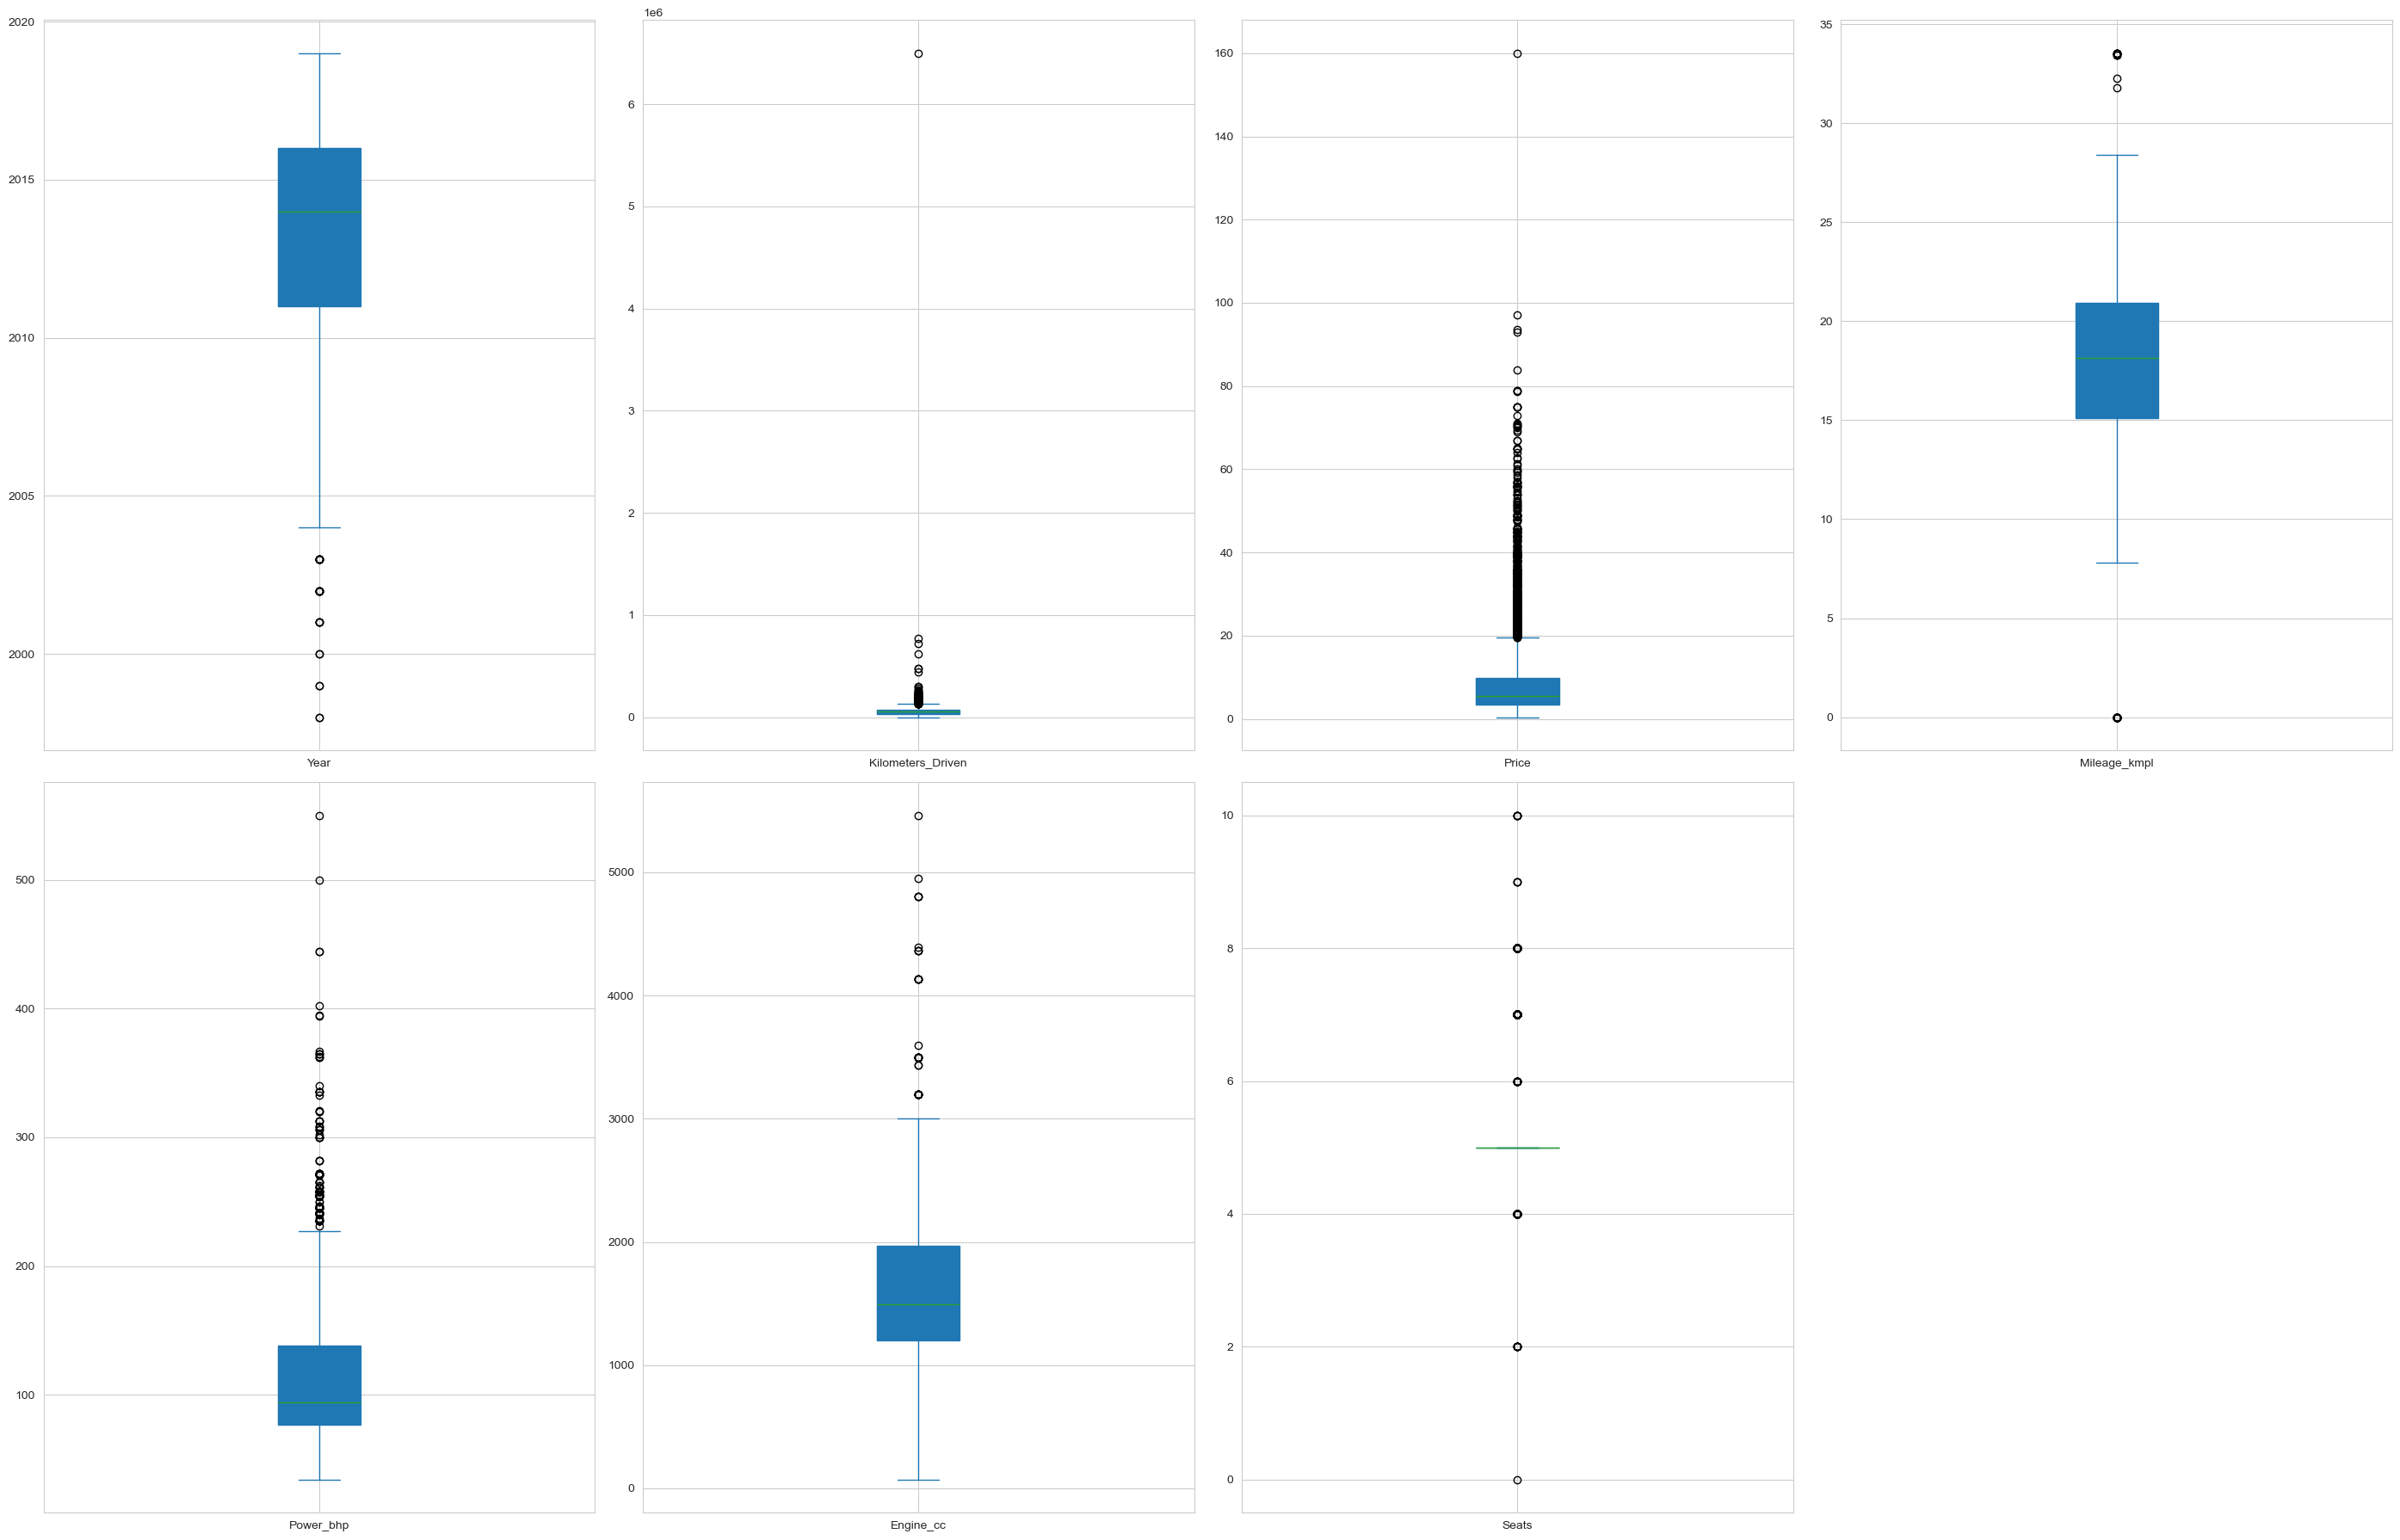

In [33]:
sns.set_style('whitegrid')
axes=train[numeric_cols].plot(kind='box',subplots=True,sharey=False,layout=(2,int(len(numeric_cols)/2)+1),figsize=(28,18),patch_artist=True)
for ax,c in zip(axes,sns.color_palette('Set2',len(numeric_cols))):
    for p in ax.artists:p.set_facecolor(c);p.set_alpha(0.85)
plt.tight_layout()
plt.show()

In [34]:
train[train['Seats']==0]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price,Brand,Model
3999,Audi A4 3.2 FSI Tiptronic Quattro,Hyderabad,2012,125000,Petrol,Automatic,First,10.5,3197.0,94.0,0.0,18.0,Audi,A4 3.2 FSI Tiptronic Quattro


In [35]:
train[train['Seats']==10]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price,Brand,Model
814,Toyota Qualis FS B2,Pune,2004,77757,Diesel,Manual,Second,13.10,2446.0,75.0,10.0,3.50,Toyota,Qualis FS B2
917,Tata Sumo DX,Mumbai,2013,20000,Diesel,Manual,First,14.07,1978.0,83.1,10.0,5.25,Tata,Sumo DX
1907,Toyota Qualis FS B3,Bangalore,2002,63000,Diesel,Manual,Third,13.10,2446.0,75.0,10.0,3.65,Toyota,Qualis FS B3
2267,Toyota Qualis RS E2,Pune,2004,215750,Diesel,Manual,Second,0.00,2446.0,94.0,10.0,3.50,Toyota,Qualis RS E2
2575,Chevrolet Tavera LS B3 10 Seats BSIII,Hyderabad,2015,120000,Diesel,Manual,First,14.80,2499.0,80.0,10.0,5.50,Chevrolet,Tavera LS B3 10 Seats BSIII


In [36]:
train[train['Year']<=2000]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price,Brand,Model
315,Tata Sumo Delux,Hyderabad,2000,158000,Diesel,Manual,Second,14.07,2956.0,83.1,7.0,1.50,Tata,Sumo Delux
613,Mahindra Bolero ZLX BSIII,Kolkata,2000,124000,Diesel,Manual,First,13.60,2523.0,63.0,7.0,1.95,Mahindra,Bolero ZLX BSIII
1224,Maruti Zen VX,Jaipur,1999,70000,Petrol,Manual,Second,17.30,993.0,60.0,5.0,0.77,Maruti,Zen VX
1845,Honda City 1.3 EXI,Pune,1999,140000,Petrol,Manual,First,13.00,1343.0,90.0,5.0,0.90,Honda,City 1.3 EXI
3138,Maruti Zen LXI,Jaipur,1998,95150,Petrol,Manual,Third,17.30,993.0,60.0,5.0,0.45,Maruti,Zen LXI
3749,Mercedes-Benz E-Class 250 D W 210,Mumbai,1998,55300,Diesel,Automatic,First,10.00,1796.0,157.7,5.0,3.90,Mercedes-Benz,E-Class 250 D W 210


In [37]:
train[train['Kilometers_Driven']>=6.000000e+06]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price,Brand,Model
2328,BMW X5 xDrive 30d M Sport,Chennai,2017,6500000,Diesel,Automatic,First,15.97,2993.0,258.0,5.0,65.0,Bmw,X5 xDrive 30d M Sport


In [38]:
train['Kilometers_Driven'] = train.groupby(['Brand','Year'])['Kilometers_Driven'].transform(lambda x: x.mask(x>600000, x.median()))

In [39]:
train[train['Mileage_kmpl']>30]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price,Brand,Model
1269,Maruti Alto 800 2016-2019 CNG LXI,Mumbai,2018,10600,CNG,Manual,First,33.44,796.0,40.30,4.0,3.50,Maruti,Alto 800 2016-2019 CNG LXI
1332,Maruti Wagon R CNG LXI,Pune,2013,79494,CNG,Manual,First,33.54,998.0,67.04,5.0,2.96,Maruti,Wagon R CNG LXI
2059,Maruti Wagon R CNG LXI,Mumbai,2013,54000,CNG,Manual,First,33.54,998.0,67.04,5.0,3.05,Maruti,Wagon R CNG LXI
2371,Maruti Wagon R CNG LXI,Pune,2014,29202,CNG,Manual,First,33.54,998.0,67.04,5.0,3.90,Maruti,Wagon R CNG LXI
2701,Maruti Celerio CNG VXI MT,Kochi,2016,70536,CNG,Manual,First,31.79,998.0,58.33,5.0,4.58,Maruti,Celerio CNG VXI MT
3119,Maruti Alto K10 LXI CNG Optional,Kochi,2018,44202,CNG,Manual,First,32.26,998.0,58.20,4.0,4.00,Maruti,Alto K10 LXI CNG Optional
3129,Maruti Wagon R CNG LXI,Delhi,2014,74663,CNG,Manual,First,33.54,998.0,67.04,5.0,3.25,Maruti,Wagon R CNG LXI
3553,Maruti Alto 800 2016-2019 CNG LXI,Pune,2015,18000,CNG,Manual,First,33.44,796.0,40.30,4.0,3.00,Maruti,Alto 800 2016-2019 CNG LXI
3869,Maruti Alto 800 2016-2019 CNG LXI,Delhi,2012,65537,CNG,Manual,Second,33.44,796.0,40.30,4.0,2.10,Maruti,Alto 800 2016-2019 CNG LXI
4141,Maruti Wagon R CNG LXI,Mumbai,2014,47200,CNG,Manual,First,33.54,998.0,67.04,5.0,2.85,Maruti,Wagon R CNG LXI


In [40]:
train.groupby('Fuel_Type')['Mileage_kmpl'].describe()

,count,mean,std,min,25%,50%,75%,max
Fuel_Type,,,,,,,,
CNG,44.0,25.344545,5.886832,13.20,22.10,26.30,26.830,33.54
Diesel,2393.0,18.597814,4.905691,0.00,14.84,19.00,22.540,28.40
Electric,1.0,18.150000,NaN,18.15,18.15,18.15,18.150,18.15
LPG,8.0,17.681250,4.481146,13.45,13.45,17.30,19.675,26.20
Petrol,2068.0,17.362350,3.830352,0.00,15.60,17.80,19.400,26.00


In [41]:
mask=train['Mileage_kmpl']<=0
train.loc[mask,'Mileage_kmpl']=train.groupby('Fuel_Type')['Mileage_kmpl'].transform('median')[mask]
mask=test['Mileage_kmpl']<=0
test.loc[mask,'Mileage_kmpl']=test.groupby('Fuel_Type')['Mileage_kmpl'].transform('median')[mask]

In [42]:
mask=train['Seats']<=1
train.loc[mask,'Seats']=train.groupby('Brand')['Seats'].transform('median')[mask]
mask=test['Seats']<=1
test.loc[mask,'Seats']=test.groupby('Brand')['Seats'].transform('median')[mask]

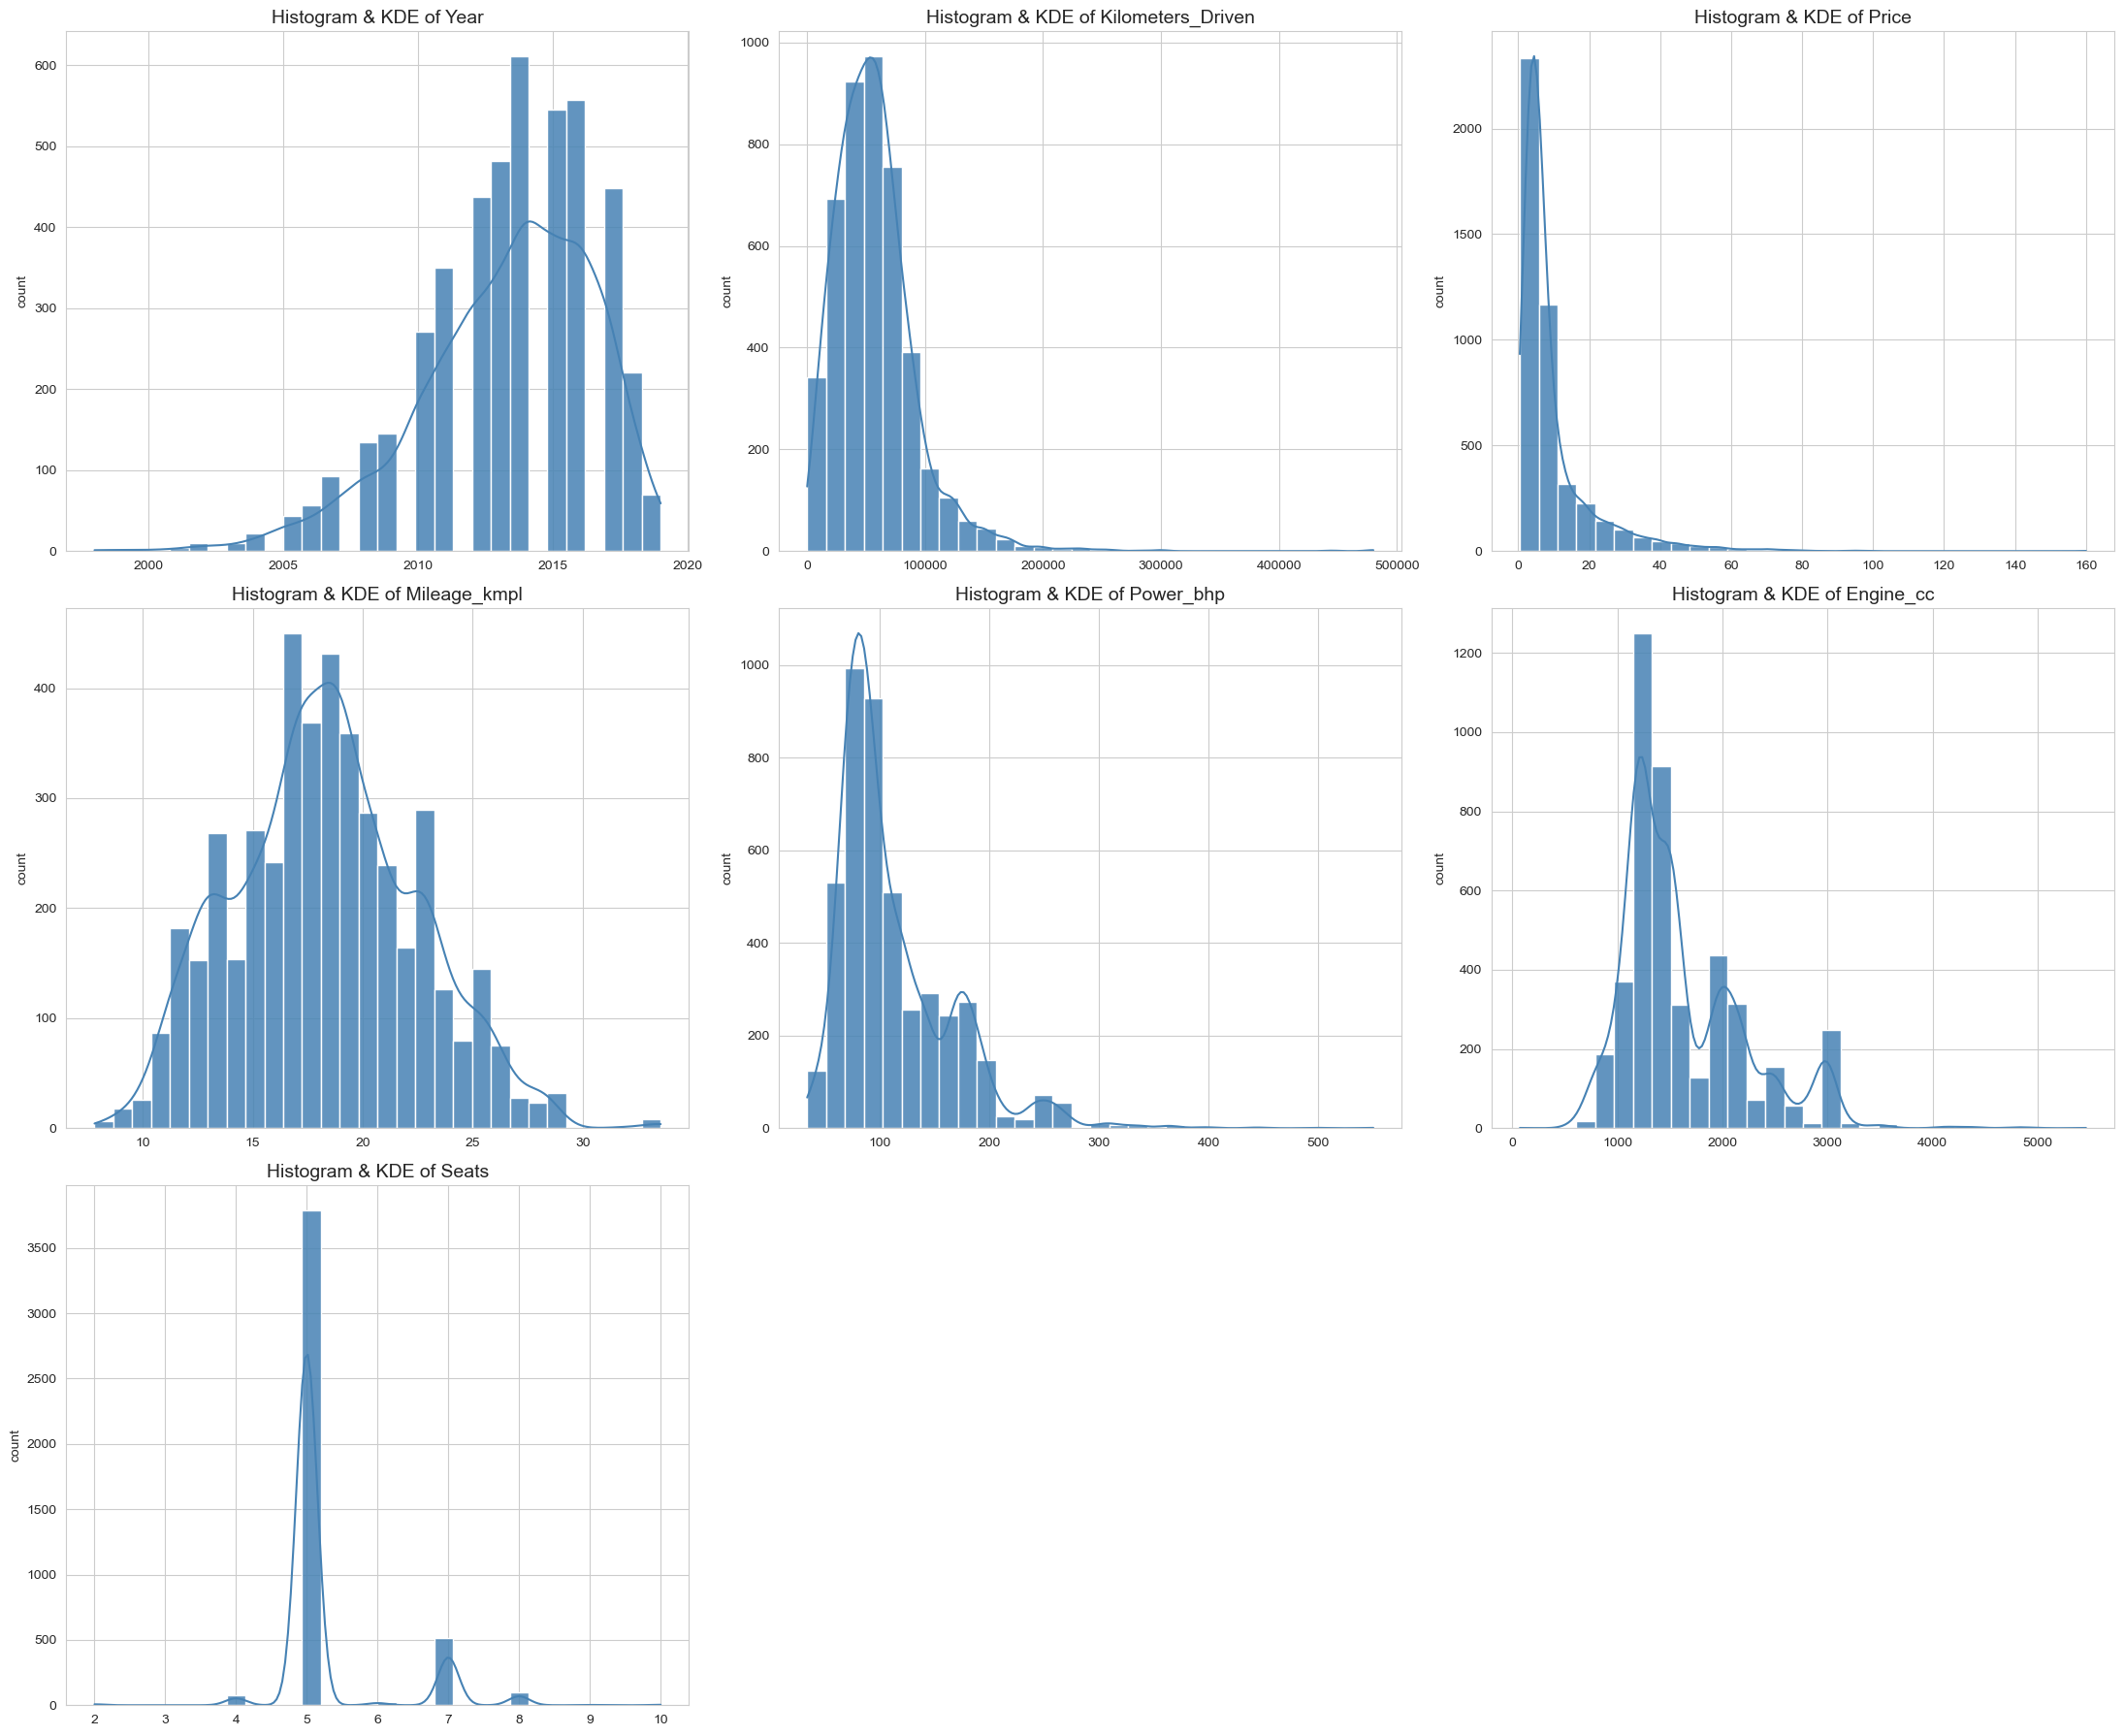

In [43]:

sns.set_style('whitegrid')
plt.figure(figsize=(22,18))
for i,f in enumerate(numeric_cols):
    plt.subplot(3,3,i+1)
    sns.histplot(train[f],bins=30,color='steelblue',kde=True,edgecolor='white',alpha=0.85)
    plt.title(f'Histogram & KDE of {f}',fontsize=14)
    plt.xlabel('')
    plt.ylabel('count')
plt.tight_layout()
plt.show()

In [44]:
categorical_cols+=['Brand','Model']


C:\Users\Ghazal\AppData\Local\Temp\ipykernel_12208\1184159293.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g=sns.catplot(data=train,y= col,kind='count',palette='pastel',height=5,aspect=2)
C:\Users\Ghazal\AppData\Local\Temp\ipykernel_12208\1184159293.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g=sns.catplot(data=train,y= col,kind='count',palette='pastel',height=5,aspect=2)
C:\Users\Ghazal\AppData\Local\Temp\ipykernel_12208\1184159293.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g=sns.catplot(data=train,y= col,kind='count',palette='pastel',height=5,aspect=2

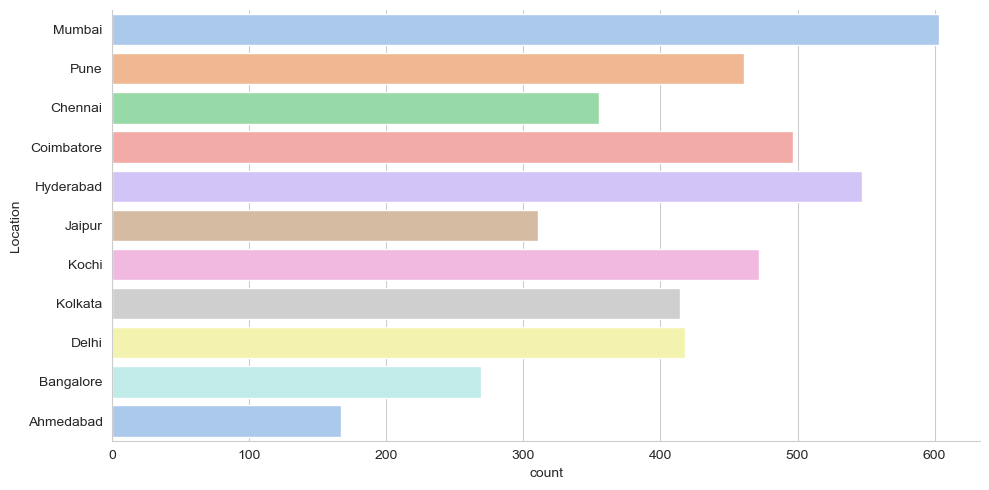

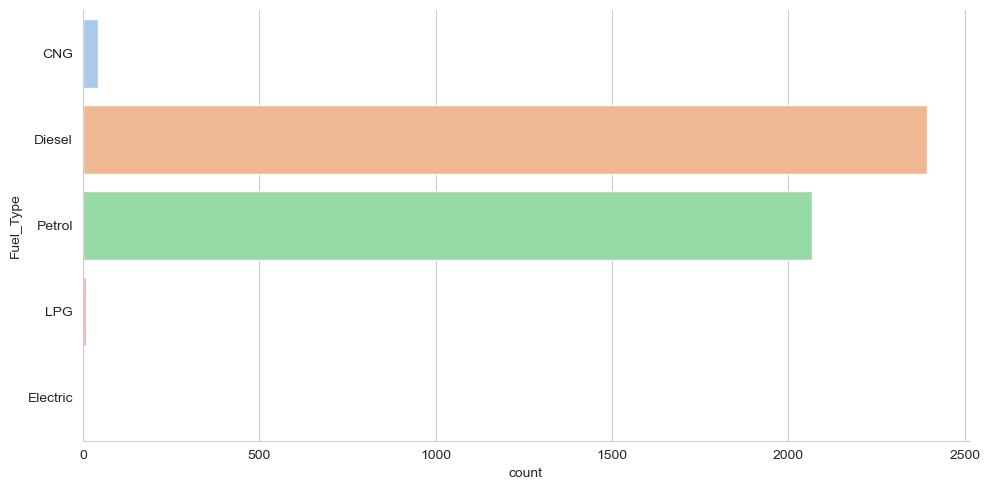

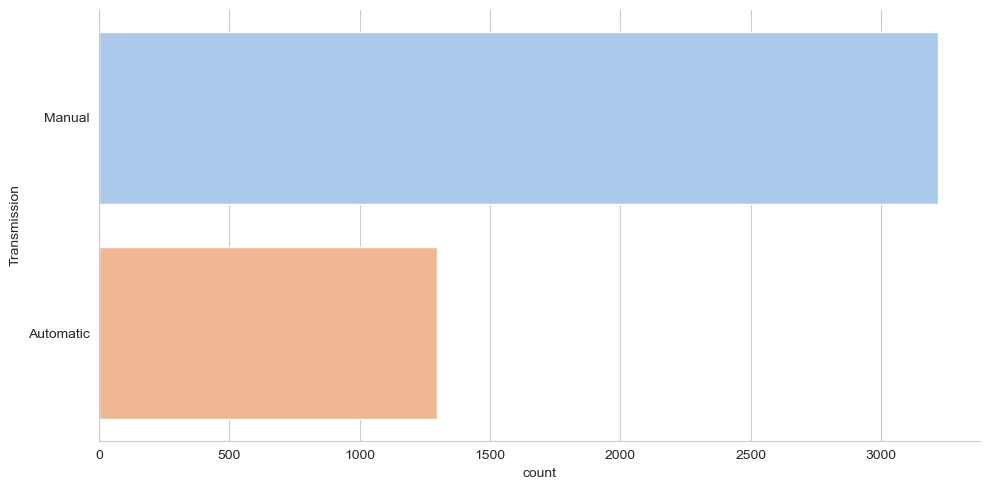

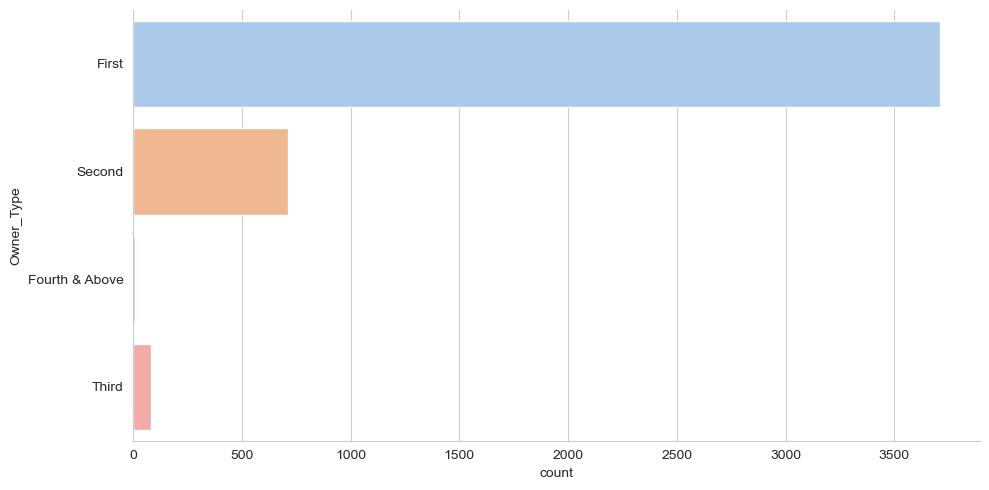

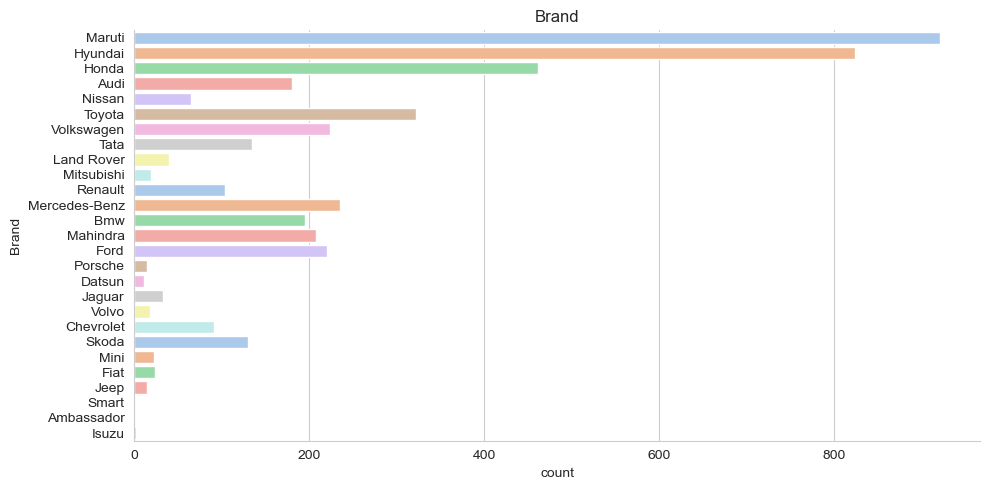

In [45]:
catplotcols=[c for c in categorical_cols if c not in ['Model','Name']]
for col in catplotcols:
    g=sns.catplot(data=train,y= col,kind='count',palette='pastel',height=5,aspect=2)
plt.title(col)
plt.tight_layout()

plt.show()

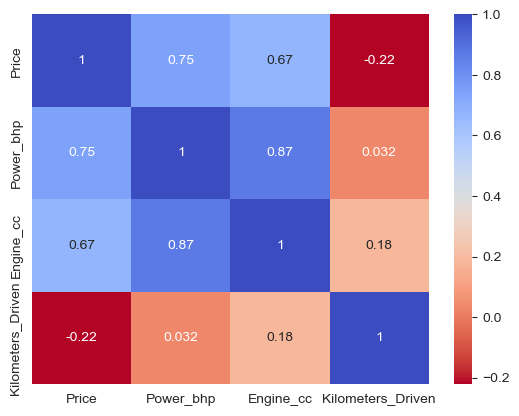

In [46]:
sns.heatmap(train[['Price','Power_bhp','Engine_cc','Kilometers_Driven']].corr(method='spearman'),annot=True,cmap='coolwarm_r')
plt.show()

<p dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium;color:#0099cc"><font face="vazir" size=3><i> قیمت با قدرت موتور و حجم موتور خیلی رابطه داره هرچی موتور قوی تر و سی سی بالاتر باشه قیمت هم بالاتر میره اما با کیلومترهای طی شده رابطه خیلی کمی داره یعنی ماشینایی که کارکرد بالاتری دارن کمی ارزونترن بین خود متغیرها هم مشخص شد قدرت موتور و حجم موتور خیلی با هم همبسته هستن یعنی معمولاً موتورای بزرگ قدرت بیشتری هم دارن اما قدرت و کارکرد تقریبا هیچ ربطی به هم ندارن و حجم موتور هم فقط کمی با کارکرد رابطه داره 
</i></font></p>

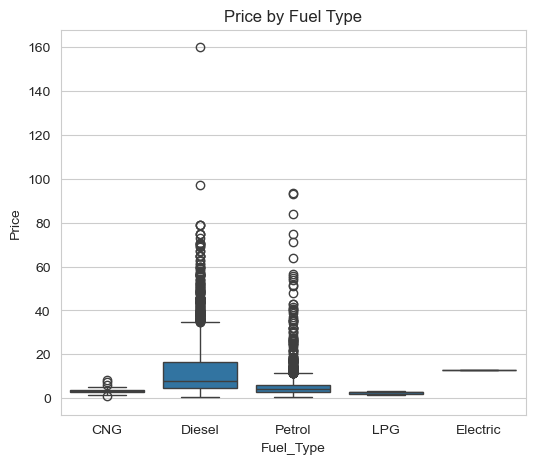

In [47]:

plt.figure(figsize=(6,5))
sns.boxplot(x='Fuel_Type',y='Price',data=train)
plt.title('Price by Fuel Type')
plt.show()

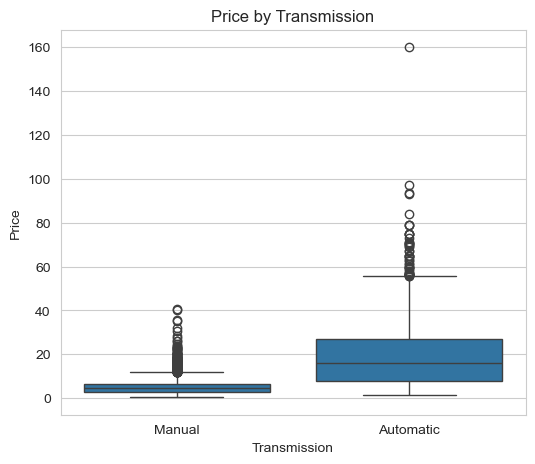

In [48]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Transmission',y='Price',data=train)
plt.title('Price by Transmission')
plt.show()

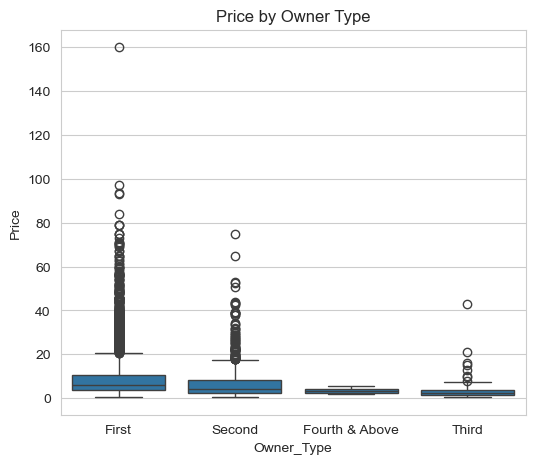

In [49]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Owner_Type', y='Price', data=train)
plt.title('Price by Owner Type')
plt.show()

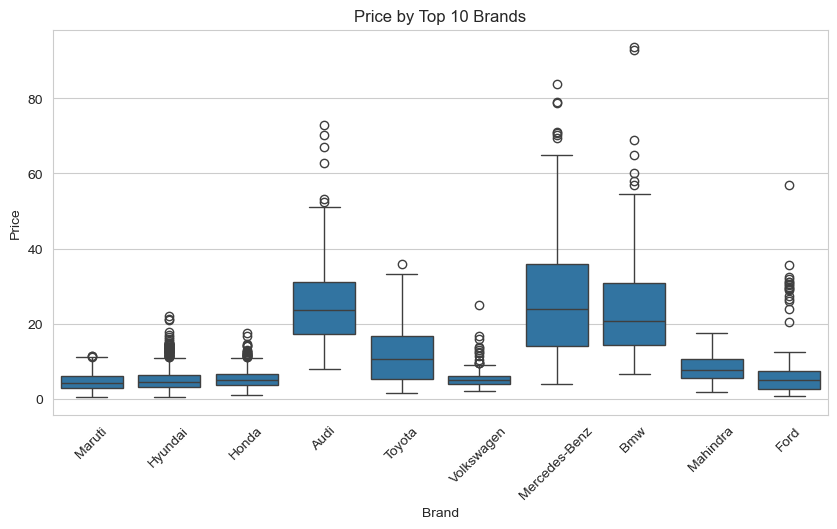

In [50]:
top_brands = train['Brand'].value_counts().head(10).index
plt.figure(figsize=(10,5))
sns.boxplot(x='Brand', y='Price', data=train[train['Brand'].isin(top_brands)])
plt.xticks(rotation=45)
plt.title('Price by Top 10 Brands')
plt.show()

In [51]:
train[train['Price']==160]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price,Brand,Model
4079,Land Rover Range Rover 3.0 Diesel LWB Vogue,Hyderabad,2017,25000,Diesel,Automatic,First,13.33,2993.0,255.0,5.0,160.0,Land Rover,Range Rover 3.0 Diesel LWB Vogue


In [52]:
land_rover=train[train['Brand']=='Land Rover']
land_rover

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price,Brand,Model
13,Land Rover Range Rover 2.2L Pure,Delhi,2014,72000,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,27.00,Land Rover,Range Rover 2.2L Pure
14,Land Rover Freelander 2 TD4 SE,Pune,2012,85000,Diesel,Automatic,Second,19.00,2179.0,115.00,5.0,17.50,Land Rover,Freelander 2 TD4 SE
191,Land Rover Range Rover 2.2L Dynamic,Coimbatore,2018,36091,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,55.76,Land Rover,Range Rover 2.2L Dynamic
311,Land Rover Range Rover HSE Dynamic,Delhi,2017,44000,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,44.00,Land Rover,Range Rover HSE Dynamic
399,Land Rover Range Rover 2.2L Dynamic,Hyderabad,2012,56000,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,30.00,Land Rover,Range Rover 2.2L Dynamic
404,Land Rover Range Rover 2.2L Prestige,Coimbatore,2017,34990,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,53.83,Land Rover,Range Rover 2.2L Prestige
410,Land Rover Range Rover 2.2L Pure,Coimbatore,2014,95649,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,29.67,Land Rover,Range Rover 2.2L Pure
480,Land Rover Range Rover Evoque 2.0 TD4 Pure,Delhi,2015,24000,Diesel,Automatic,Second,15.68,1999.0,177.00,5.0,33.50,Land Rover,Range Rover Evoque 2.0 TD4 Pure
521,Land Rover Range Rover HSE Dynamic,Coimbatore,2017,49275,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,45.64,Land Rover,Range Rover HSE Dynamic
701,Land Rover Freelander 2 SE,Chennai,2011,109000,Diesel,Automatic,First,12.39,2179.0,147.51,5.0,16.50,Land Rover,Freelander 2 SE


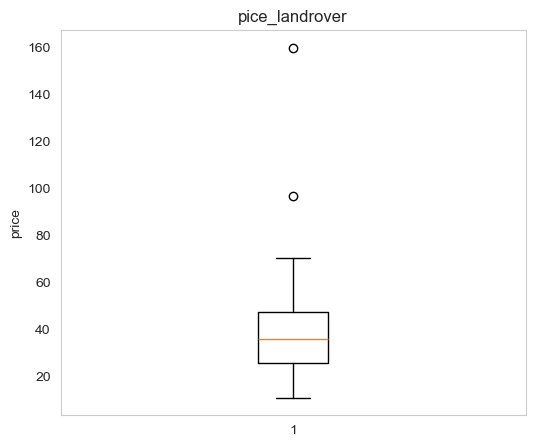

In [53]:
plt.figure(figsize=(6,5))
plt.boxplot(land_rover['Price'])
plt.title('pice_landrover')
plt.ylabel('price')
plt.grid()
plt.show()

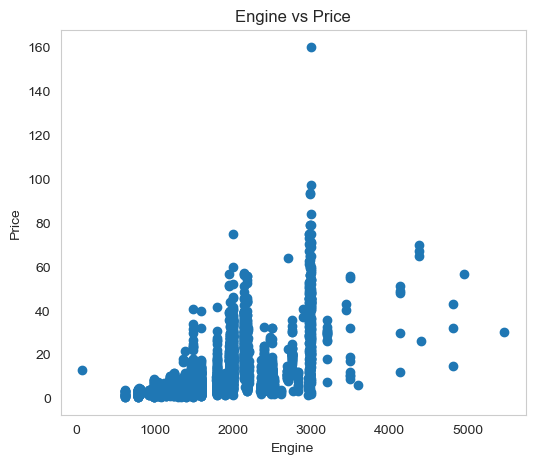

In [54]:
plt.figure(figsize=(6,5))
plt.scatter(train['Engine_cc'], train['Price'])
plt.title('Engine vs Price')
plt.xlabel('Engine')
plt.ylabel('Price')
plt.grid()
plt.show()

In [55]:
mask = ((train['Brand']=='Land Rover') &(train['Model'].str.startswith('Range Rover')) &(train['Year'].between(2015, 2019)) &
    (train['Fuel_Type']=='Diesel'))
train.loc[mask & (train['Price'] >= 120), 'Price'] = train.loc[mask, 'Price'].median()

In [56]:
test['Price_temp'] = np.nan
mask_test = ((test['Brand']=='Land Rover') &(test['Model'].str.startswith('Range Rover', na=False))&
    (test['Year'].between(2015, 2019))&(test['Fuel_Type'] == 'Diesel'))
test.loc[mask_test, 'Price_temp'] = train.loc[mask, 'Price'].median()

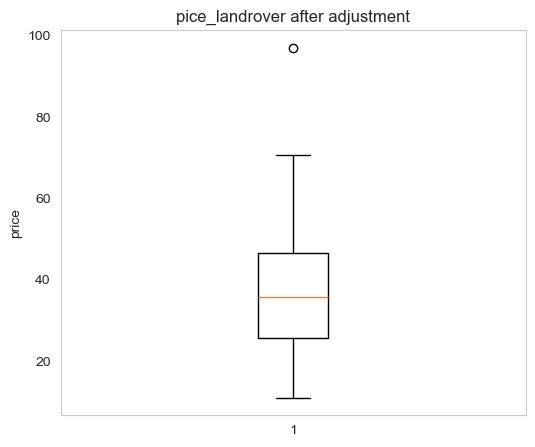

In [57]:
plt.figure(figsize=(6,5))
plt.boxplot(train.loc[train['Brand']=='Land Rover','Price'])
plt.title('pice_landrover after adjustment')
plt.ylabel('price')
plt.grid()
plt.show()

In [58]:
land_rover=train[train['Brand']=='Land Rover']
land_rover

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price,Brand,Model
13,Land Rover Range Rover 2.2L Pure,Delhi,2014,72000,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,27.000,Land Rover,Range Rover 2.2L Pure
14,Land Rover Freelander 2 TD4 SE,Pune,2012,85000,Diesel,Automatic,Second,19.00,2179.0,115.00,5.0,17.500,Land Rover,Freelander 2 TD4 SE
191,Land Rover Range Rover 2.2L Dynamic,Coimbatore,2018,36091,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,55.760,Land Rover,Range Rover 2.2L Dynamic
311,Land Rover Range Rover HSE Dynamic,Delhi,2017,44000,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,44.000,Land Rover,Range Rover HSE Dynamic
399,Land Rover Range Rover 2.2L Dynamic,Hyderabad,2012,56000,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,30.000,Land Rover,Range Rover 2.2L Dynamic
404,Land Rover Range Rover 2.2L Prestige,Coimbatore,2017,34990,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,53.830,Land Rover,Range Rover 2.2L Prestige
410,Land Rover Range Rover 2.2L Pure,Coimbatore,2014,95649,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,29.670,Land Rover,Range Rover 2.2L Pure
480,Land Rover Range Rover Evoque 2.0 TD4 Pure,Delhi,2015,24000,Diesel,Automatic,Second,15.68,1999.0,177.00,5.0,33.500,Land Rover,Range Rover Evoque 2.0 TD4 Pure
521,Land Rover Range Rover HSE Dynamic,Coimbatore,2017,49275,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,45.640,Land Rover,Range Rover HSE Dynamic
701,Land Rover Freelander 2 SE,Chennai,2011,109000,Diesel,Automatic,First,12.39,2179.0,147.51,5.0,16.500,Land Rover,Freelander 2 SE


array([[<Axes: xlabel='Year', ylabel='Year'>,
        <Axes: xlabel='Kilometers_Driven', ylabel='Year'>,
        <Axes: xlabel='Mileage_kmpl', ylabel='Year'>,
        <Axes: xlabel='Engine_cc', ylabel='Year'>,
        <Axes: xlabel='Power_bhp', ylabel='Year'>,
        <Axes: xlabel='Seats', ylabel='Year'>,
        <Axes: xlabel='Price', ylabel='Year'>],
       [<Axes: xlabel='Year', ylabel='Kilometers_Driven'>,
        <Axes: xlabel='Kilometers_Driven', ylabel='Kilometers_Driven'>,
        <Axes: xlabel='Mileage_kmpl', ylabel='Kilometers_Driven'>,
        <Axes: xlabel='Engine_cc', ylabel='Kilometers_Driven'>,
        <Axes: xlabel='Power_bhp', ylabel='Kilometers_Driven'>,
        <Axes: xlabel='Seats', ylabel='Kilometers_Driven'>,
        <Axes: xlabel='Price', ylabel='Kilometers_Driven'>],
       [<Axes: xlabel='Year', ylabel='Mileage_kmpl'>,
        <Axes: xlabel='Kilometers_Driven', ylabel='Mileage_kmpl'>,
        <Axes: xlabel='Mileage_kmpl', ylabel='Mileage_kmpl'>,
        <Axes:

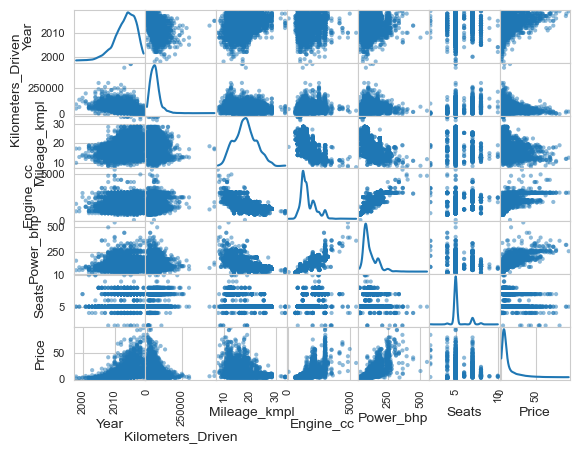

In [59]:
pd.plotting.scatter_matrix(train, diagonal='kde')

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">مهندسی ویژگی</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
طبق بررسی‌هایی که از داده‌ها داشته‌اید یا جهت دست‌یابی به عملکرد بهتر در مدل‌های پیش‌بینی‌کننده‌ی خود ممکن است به مهندسی ویژگی‌‌ها (کدگذاری متغیر هدف،‌ حذف ویژگی‌ها، تغییر نوع ویژگی‌ها، ساخت ویژگی جدید، تغییر مقیاس و غیره) نیاز داشته باشید. در این‌صورت می‌توانید در این قسمت از هر روش یا ابزاری که مناسب می‌دانید به‌منظور مهندسی ویژگی‌ها استفاده کنید.
</font>
</p>

In [60]:
train.drop(columns=['Name','Location'],inplace=True)
test.drop(columns=['Name','Location'],inplace=True)

In [61]:
train=pd.get_dummies(train,columns=['Fuel_Type','Transmission','Owner_Type','Brand'],drop_first=True)

model_freq = train['Model'].value_counts()
train['Model_freq']=train['Model'].map(model_freq)
test['Model_freq']=test['Model'].map(model_freq).fillna(0)
train.drop(columns='Model', inplace=True)
test.drop(columns='Model', inplace=True)

In [62]:
test=pd.get_dummies(test,columns=['Fuel_Type','Transmission','Owner_Type','Brand'],drop_first=True)

In [63]:

train['Car_age']=2020-train['Year']
test['Car_age']=2020-test['Year']



In [64]:
train.describe()

,Year,Kilometers_Driven,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price,Model_freq,Car_age
count,4514.000000,4514.000000,4514.000000,4514.000000,4514.000000,4514.000000,4514.000000,4514.000000,4514.000000
mean,2013.365086,57246.710013,18.305687,1617.109437,112.487453,5.281790,9.429190,6.733274,6.634914
std,3.225629,35280.636684,4.112915,587.337285,52.199257,0.804591,10.909573,6.749627,3.225629
min,1998.000000,171.000000,7.810000,72.000000,34.200000,2.000000,0.440000,1.000000,1.000000
25%,2011.000000,34000.000000,15.400000,1198.000000,76.925000,5.000000,3.500000,2.000000,4.000000
50%,2014.000000,53000.000000,18.195000,1493.000000,94.000000,5.000000,5.600000,4.000000,6.000000
75%,2016.000000,72926.250000,20.920000,1968.000000,138.100000,5.000000,9.942500,9.000000,9.000000
max,2019.000000,480000.000000,33.540000,5461.000000,550.000000,10.000000,97.070000,37.000000,22.000000


In [65]:
test.describe()

,Year,Kilometers_Driven,Mileage_kmpl,Engine_cc,Power_bhp,Seats,Price_temp,Model_freq,Car_age
count,1505.000000,1505.000000,1505.000000,1505.000000,1505.000000,1505.000000,0.0,1505.000000,1505.000000
mean,2013.337542,57640.272425,18.448106,1630.313621,113.334023,5.265116,NaN,5.631894,6.662458
std,3.399637,34076.229226,4.265362,635.365794,56.741900,0.800274,NaN,6.764664,3.399637
min,1998.000000,600.000000,6.400000,624.000000,35.000000,2.000000,NaN,0.000000,1.000000
25%,2011.000000,34000.000000,15.400000,1198.000000,74.960000,5.000000,NaN,1.000000,4.000000
50%,2014.000000,53280.000000,18.200000,1497.000000,94.000000,5.000000,NaN,3.000000,6.000000
75%,2016.000000,73000.000000,21.400000,1984.000000,138.000000,5.000000,NaN,8.000000,9.000000
max,2019.000000,250000.000000,33.440000,5998.000000,560.000000,8.000000,NaN,37.000000,22.000000


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">مدل‌سازی</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
اکنون می‌توانید با استفاده از الگوریتم‌های یادگیری ماشین، مدلی آموزش دهید که با گرفتن مقادیر ویژگی‌های موجود در دادگان، قیمت خودرو را پیش‌بینی کند.
در این قسمت از شما می‌خواهیم از الگوریتم‌های <b> Regression </b> استفاده کنید و ترکیب‌های مختلفی از هایپرپارامترهای مهم این الگوریتم‌ها را آزمایش کنید تا بهترین مدل را برای پیش‌بینی قیمت خودرو انتخاب کنید. شما می‌توانید برای این منظور،حداقل دو-سه مدل یادگیری ماشینی<b> Regression</b>   را مورد بررسی قرار دهید. در این قسمت می‌توانید از کتابخانه‌ی <code>sklearn</code> استفاده کنید و برای جست‌وجوی هایپرپارامترها می‌توانید از روشی همچون Grid Search استفاده کنید. منطقی است که برای پیدا کردن بهترین ترکیب هایپرپارامتر نیاز به مجموعه‌ی اعتبارسنجی یا استفاده از روش‌هایی مانند Cross Validation دارید.
</font>
</p>

In [66]:

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

In [67]:
features=train.drop('Price',axis=1)
label=train['Price']
features_train,features_validation,label_train,label_validation=train_test_split(features,label,test_size=0.2,random_state=40)
len(features_train),len(features_validation),len(label_train),len(label_validation)

(3611, 903, 3611, 903)

In [68]:
model_reg_lin = LinearRegression()
model_reg_lin.fit(features_train,label_train)
pred_lr = model_reg_lin.predict(features_validation)
r2 = r2_score(label_validation, pred_lr)
print("Linear Regression R2:", r2)

Linear Regression R2: 0.7519097434260069


In [69]:
model_reg_ridge = Ridge(alpha=10)

model_reg_ridge.fit(features_train,label_train)

y_pred = model_reg_ridge.predict(features_train)
r2 = r2_score(y_true=label_train.ravel(), y_pred=y_pred)
print(f'reg ridge: {r2}')

reg ridge: 0.77331831389252


C:\Users\Ghazal\AppData\Local\Temp\ipykernel_12208\2858723753.py:6: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  r2 = r2_score(y_true=label_train.ravel(), y_pred=y_pred)


In [70]:
model_reg_lasso = Lasso(alpha=0.01)

model_reg_lasso.fit(features_train,label_train)

y_pred = model_reg_lasso.predict(features_train)
r2 = r2_score(y_true=label_train.ravel(), y_pred=y_pred)
print(f'reg lasso : {r2}')

reg lasso : 0.7780143937862091


C:\Users\Ghazal\AppData\Local\Temp\ipykernel_12208\1474319741.py:6: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  r2 = r2_score(y_true=label_train.ravel(), y_pred=y_pred)


In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

In [72]:
test = test.drop(columns=['Price_temp'], errors='ignore')
test = test.reindex(columns=features_train.columns, fill_value=0)

In [73]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([('scaler', StandardScaler()),('lasso', Lasso(max_iter=10000))])

param_grid = {'lasso__alpha': [0.001, 0.01,0.1,1,10]}
lasso_grid = GridSearchCV(pipe, param_grid,cv=5, scoring='r2')
lasso_grid.fit(features_train, label_train)
print("Best alpha:", lasso_grid.best_params_)
print("Train R2:", lasso_grid.score(features_train, label_train))
print("Validation R2:", lasso_grid.score(features_validation, label_validation))


Best alpha: {'lasso__alpha': 0.01}
Train R2: 0.7803460145421571
Validation R2: 0.751895991312486


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
با توجه به نتایجی که بر روی هر ترکیب هایپرپارامتر به دست آورده‌اید،‌ تاثیر هر یک از هایپرپارامترها را بر روی عملکرد مدل چه می‌دانید؟ دلایل و تحلیل خود را در سلول زیر بنویسید:
<span style="color:red">(ضروری)</span>
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium;color:#0099cc"><font face="vazir" size=3><i>
[تحلیل شما]
</i></font></p>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
حال نتایج مدل نهایی انتخاب‌شده را هم بر روی مجموعه‌ی آموزشی و هم اعتبارسنجی گزارش کنید.
</font>
</p>

In [74]:
# To-Do (Evaluation)

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">پیش‌بینی برای مجموعه‌ی آزمون</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
اکنون از مدلی که آموزش داده‌اید برای پیش‌بینی نمونه‌های مجموعه‌ی آزمون استفاده کرده تا متوجه شوید که مدل شما تا چه میزان برای نمونه‌های جدید و مشاهده‌نشده موفق عمل می‌کند. نیاز است پیش‌بینی‌های مدل خود را در یک دیتافریم با نام <code>submission</code> که شامل یک ستون به نام <code>Price</code> است ذخیره کنید. ردیف اول از این دیتافریم، پیش‌بینی مدل شما برای نمونه‌ی نخست و ردیف آخر از آن،‌ پیش‌بینی مدل شما برای نمونه‌ی آخر مجموعه‌ی آزمون است. توجه داشته باشید که مقادیر این ستون باید از جنس دسته‌ای و مشابه با مقادیر آن در مجموعه‌ی آموزشی باشد. یک نمونه‌ی فرضی از دیتافریم شما در جدول زیر نشان داده شده است:
</font>
</p>

<center>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

| <code>Price</code> |
| :---: |
| 6.70 |
| 31.20 |
| 14.58 |
| 10.45 |
| ... |

</font>
</p>
</center>

In [75]:
test = test.reindex(columns=features_train.columns)
label_test_pred = lasso_grid.predict(test)
submission = pd.DataFrame({'Price': label_test_pred})
submission['Price']=submission['Price'].clip(lower=0)
submission

,Price
0,6.902466
1,6.500696
2,6.998712
3,10.670528
4,4.230978
...,...
1500,5.209844
1501,4.153076
1502,6.673467
1503,2.908677


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">ارزیابی</font>
</h2>


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
معیاری که برای ارزیابی مدل شما استفاده خواهد شد <code>r2-score</code> نام دارد. جهت مطالعه‌ی مستندات این کلاس می‌توانید به <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html" target="_blank">این لینک</a> مراجعه فرمایید.
</font>
</p>


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
<span style="color:red"><b>توجه:</b></span>
جهت کسب امتیاز کامل نیاز است پاسخ شما حداقل مقدار(درصد) <code>60</code> را با توجه به این معیار کسب کند.
<br>
<span style="color:orange"><b>نکته:</b></span>
برای پاسخ‌هایی که عملکردی کمتر از این حد آستانه کسب کنند، امتیاز <code>0</code> منظور می‌شود و برای عملکردهایی بهتر از این حد آستانه،‌ به همان میزان، نمره‌ی اضافه برای این بخش در نظر گرفته خواهد شد.
<br>
<span style="color:orange"><b>نکته:</b></span>
از ذخیره بودن نت‌بوک خود در ارسال نهایی اطمینان حاصل کنید زیرا که نت‌بوک شما نیز مورد داوری دستی قرار خواهد گرفت و نمره‌ی نهایی شما از ترکیب نمره‌ی پیش‌بینی مدل و نمره‌ی داوری دستی (راه‌حل و تحلیل) محاسبه خواهد شد.
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید. توجه داشته باشید که پیش از اجرای سلول زیر تغییرات اعمال شده در نت‌بوک را ذخیره کرده باشید (<code>ctrl+s</code>) تا امکان بررسی کد شما وجود داشته باشد.
</font>
</p>

In [76]:
import zipfile
import joblib

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)

submission.to_csv('submission.csv', index=False)
file_names = ['used_cars.ipynb', 'submission.csv']
compress(file_names)

File Paths:
['used_cars.ipynb', 'submission.csv']
